In [81]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [82]:

df_preprocessed= pd.read_csv('data/data_cleaned.csv')
# Log-transform target & continuous skewed vars
df_preprocessed['price'] = np.log1p(df_preprocessed['price'])
df_preprocessed['habitablesurface'] = np.log1p(df_preprocessed['habitablesurface'])

"""features = [
    'type_encoded', 'bedroomcount', 'buildingcondition_encoded', 'epcscore_encoded',
    'region_Brussels', 'region_Flanders', 'region_Wallonia',
    'hasswimmingpool', 'hasgarden', 'habitablesurface'
]"""

features2 = ['bedroomcount','habitablesurface','haslift','hasgarden','hasswimmingpool','hasterrace',
             'price','hasparking','epcscore_encoded','buildingcondition_encoded','region_Brussels',
             'region_Flanders','region_Wallonia','type_encoded','latitude','longitude']


In [83]:
"""df_geo = pd.read_csv('data/georef-belgium-postal-codes@public.csv', sep=';')
pc_geo_dict = {}
for pc in df_preprocessed['postcode'].unique():
    geo_point = df_geo.loc[df_geo['Post code'] == pc, 'Geo Point'].values
    if len(geo_point) > 0:
        pc_geo_dict[pc] = geo_point[0]
    else:
        pc_geo_dict[pc] = None
df_preprocessed['geocode'] = df_preprocessed['postcode'].map(pc_geo_dict)

df_preprocessed[['latitude', 'longitude']] = df_preprocessed['geocode'].str.split(',', expand=True)

df_preprocessed['latitude'] = df_preprocessed['latitude'].astype(float)
df_preprocessed['longitude'] = df_preprocessed['longitude'].astype(float)

df_preprocessed.drop(columns=['geocode'], inplace=True)

print(df_preprocessed.head())"""


"df_geo = pd.read_csv('data/georef-belgium-postal-codes@public.csv', sep=';')\npc_geo_dict = {}\nfor pc in df_preprocessed['postcode'].unique():\n    geo_point = df_geo.loc[df_geo['Post code'] == pc, 'Geo Point'].values\n    if len(geo_point) > 0:\n        pc_geo_dict[pc] = geo_point[0]\n    else:\n        pc_geo_dict[pc] = None\ndf_preprocessed['geocode'] = df_preprocessed['postcode'].map(pc_geo_dict)\n\ndf_preprocessed[['latitude', 'longitude']] = df_preprocessed['geocode'].str.split(',', expand=True)\n\ndf_preprocessed['latitude'] = df_preprocessed['latitude'].astype(float)\ndf_preprocessed['longitude'] = df_preprocessed['longitude'].astype(float)\n\ndf_preprocessed.drop(columns=['geocode'], inplace=True)\n\nprint(df_preprocessed.head())"

In [84]:
features = [
    'type_encoded', 'bedroomcount', 'buildingcondition_encoded', 'epcscore_encoded',
    'region_Brussels', 'region_Flanders', 'region_Wallonia',
    'hasswimmingpool', 'hasgarden', 'habitablesurface', 'latitude', 'longitude'
]

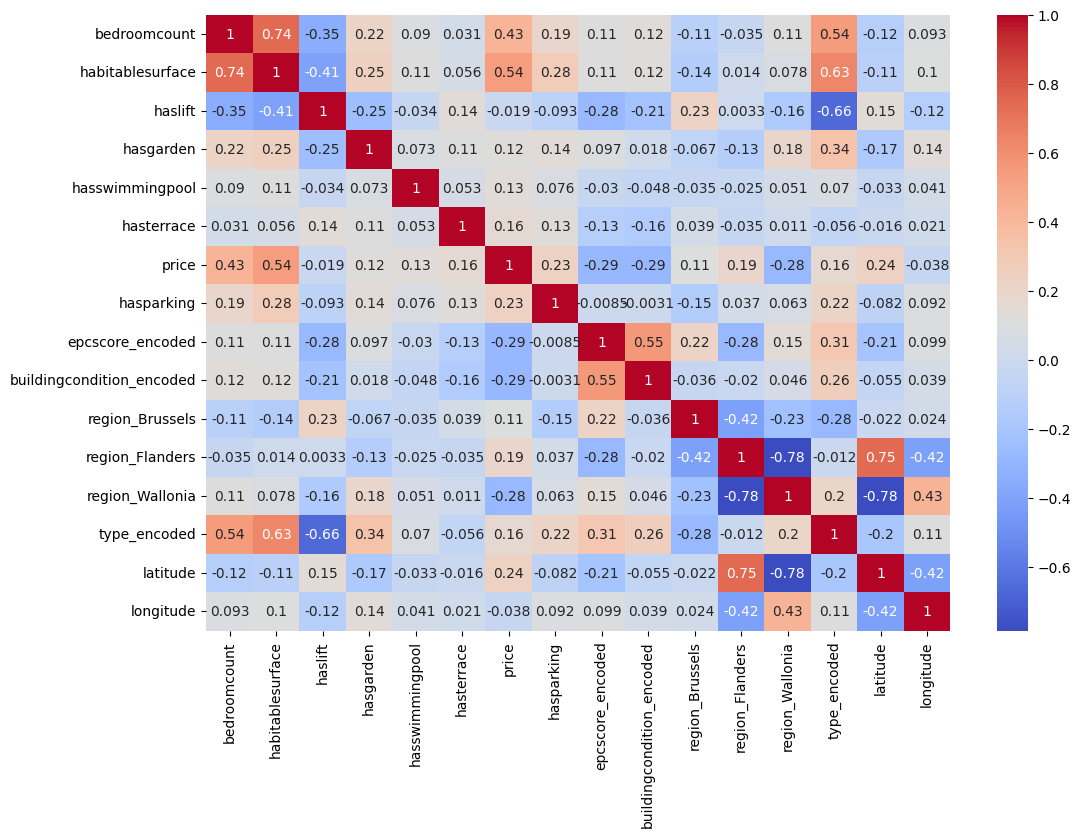

In [85]:
#corr = df_preprocessed[features + ['price']].corr()
corr = df_preprocessed[features2].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [86]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import ShuffleSplit
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

X = df_preprocessed.drop("price", axis=1).values
y = df_preprocessed["price"].values

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3,
random_state=42)

In [87]:
#polynomial features
"""poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_scaled)

cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
cross_val_score(LinearRegression(), X_poly, y, cv=cv)"""

degree = 2
model = make_pipeline(
    PolynomialFeatures(degree=degree, include_bias=False),
    LinearRegression()
)

# Fit on training data
model.fit(X_train, y_train)

# Score on test data
score = model.score(X_test, y_test)
print(f"R² score with polynomial degree {degree}: {score:.2f}")

cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)
scores = cross_val_score(model, X, y, cv=cv)
print(f"Cross-val scores: {scores}")
print(f"Mean CV score: {scores.mean():.2f}")

y_pred = model.predict(X_test)
from sklearn.metrics import root_mean_squared_error, mean_squared_error
mse=mean_squared_error(y_test, y_pred)
print(f'MSE:{mse:.2f}')
rmse=root_mean_squared_error(y_test, y_pred)
print(f'The RMSE:{rmse:.2f}')

R² score with polynomial degree 2: 0.67
Cross-val scores: [0.66654854 0.68360121 0.67436753 0.67786309 0.6720973 ]
Mean CV score: 0.67
MSE:0.08
The RMSE:0.28


In [88]:
# Regularization
from sklearn.linear_model import Ridge, Lasso

model = Ridge(alpha=1.0)  # or Lasso(alpha=0.1)
scores=cross_val_score(model, X_scaled, y, cv=cv)
print(f"Cross-val scores: {scores}")
print(f"Mean CV score: {scores.mean():.2f}")

# Fit on training data
model.fit(X_train, y_train)

# Score on test data
score = model.score(X_test, y_test)
print(f"R² score with Ridge: {score:.2f}")

y_pred = model.predict(X_test)
mse=mean_squared_error(y_test, y_pred)
print(f'MSE:{mse:.2f}')
rmse=root_mean_squared_error(y_test, y_pred)
print(f'The RMSE:{rmse:.2f}')

Cross-val scores: [0.58371429 0.60247282 0.59687805 0.59943667 0.60242399]
Mean CV score: 0.60
R² score with Ridge: 0.59
MSE:0.10
The RMSE:0.31


In [89]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
scores=cross_val_score(model, X_scaled, y, cv=cv)
print(f"Cross-val scores: {scores}")
print(f"Mean CV score: {scores.mean():.2f}")

# Fit on training data
model.fit(X_train, y_train)

# Score on test data
score = model.score(X_test, y_test)
print(f"R² score with Random Forest Regressor: {score:.2f}")

y_pred = model.predict(X_test)
mse=mean_squared_error(y_test, y_pred)
print(f'MSE:{mse:.2f}')
rmse=root_mean_squared_error(y_test, y_pred)
print(f'The RMSE:{rmse:.2f}')

Cross-val scores: [0.74397312 0.75101885 0.75247195 0.7512608  0.74069482]
Mean CV score: 0.75
R² score with Random Forest Regressor: 0.74
MSE:0.06
The RMSE:0.25


In [90]:
#Optuna

In [91]:
import plotly.graph_objects as go
#import nbformat

import plotly.io as pio
pio.renderers.default = 'browser'

fig = go.Figure(go.Bar(
            x=model.feature_importances_,
            y=features2,
            orientation='h', marker_color='steelblue'))
fig.update_layout(template='plotly_dark', title='<b>Estimating feature importance through the Random Forest model', title_x=0.5, 
                 xaxis_title="Feature importance", yaxis_title='Feature')

fig.show()

In [92]:
from sklearn.metrics import r2_score
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
df_models = pd.DataFrame(data=None, columns=['Algorithm', 'r2_train', 'r2_test'])

def make_model(X_tr, X_te, y_tr, y_te, model, model_name: str): 
    model.fit(X_tr, y_tr)
    y_pred_train = model.predict(X_tr)
    y_pred_test = model.predict(X_te)
    r2_train = r2_score(y_tr, y_pred_train)
    r2_test = r2_score(y_te, y_pred_test)
    df_models.loc[len(df_models.index)] = [model_name, r2_train, r2_test]
                       

make_model(X_train, X_test, y_train, y_test, LinearRegression(), 'LinearRegression')
make_model(X_train, X_test, y_train, y_test, Ridge(), 'Ridge')
make_model(X_train, X_test, y_train, y_test, Lasso(), 'Lasso')
make_model(X_train, X_test, y_train, y_test, ElasticNet(), 'ElasticNet')
make_model(X_train, X_test, y_train, y_test, GradientBoostingRegressor(), 'GradientBoosting')
make_model(X_train, X_test, y_train, y_test, RandomForestRegressor(), 'RandomForest')
make_model(X_train, X_test, y_train, y_test, XGBRegressor(), 'XGBoost')



In [93]:
fig = go.Figure(data=[
    go.Bar(name='r2_train', x=df_models.Algorithm, y=df_models.r2_train),
    go.Bar(name='r2_test', x=df_models.Algorithm, y=df_models.r2_test)
])
fig.update_layout(template='plotly_dark', title='R2 for train and test', title_x=0.5)

In [94]:
X_trainval, X_valid, y_trainval, y_valid = train_test_split(X_train, y_train, shuffle=True,  random_state=42)


In [95]:
import optuna

def objective(trial):
    #'tree_method':'gpu_hist',  # this parameter means using the GPU when training our model to speedup the training process
    param = {
        'sampling_method': 'uniform', #'gradient_based'
        'lambda': trial.suggest_loguniform('lambda', 7.0, 17.0),
        'alpha': trial.suggest_loguniform('alpha', 7.0, 17.0),
        'eta': trial.suggest_categorical('eta', [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]),
        'gamma': trial.suggest_categorical('gamma', [18, 19, 20, 21, 22, 23, 24, 25]),
        'learning_rate': trial.suggest_categorical('learning_rate', [0.008,0.01,0.012,0.014,0.016,0.018, 0.02]),
        #"colsample_by_tree" is the fraction of features (randomly selected) that will be used to train each tree.
        'colsample_bytree': trial.suggest_categorical('colsample_bytree', [0.3,0.4,0.5,0.6,0.7,0.8,0.9, 1.0]),
        #random subsample of columns based on every split (left or right swerve). So, every level may have 2 different subsamples if this level has left and right split. 
        'colsample_bynode': trial.suggest_categorical('colsample_bynode', [0.3,0.4,0.5,0.6,0.7,0.8,0.9, 1.0]),
        'n_estimators': trial.suggest_int('n_estimators', 400, 1000),
        'min_child_weight': trial.suggest_int('min_child_weight', 8, 600),  
        'max_depth': trial.suggest_categorical('max_depth', [3, 4, 5, 6, 7]),  
        #"subsample" is the fraction of the training samples (randomly selected) that will be used to train each tree.
        'subsample': trial.suggest_categorical('subsample', [0.5,0.6,0.7,0.8,1.0]),
        'random_state': 42
    }

    model = XGBRegressor(**param)  
    
    model.fit(X_trainval, y_trainval, eval_set=[(X_valid, y_valid)], verbose=False)
    
    predict = model.predict(X_valid)
    
    r_2 = r2_score(predict, y_valid)
    
    return r_2


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50,  timeout=600)
    
print("Number of finished trials: {}".format(len(study.trials)))
print("Best trial:")
trial = study.best_trial

print("  Value: {}".format(trial.value))

print("  Params: ")
for key, value in trial.params.items():
    print("    {}: {}".format(key, value))

[I 2025-06-30 15:14:05,446] A new study created in memory with name: no-name-87fe4890-22f3-4fbf-a057-ec9939124e5a
C:\Users\Emmanuel\AppData\Local\Temp\ipykernel_12536\3083501541.py:7: FutureWarning:

suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.

C:\Users\Emmanuel\AppData\Local\Temp\ipykernel_12536\3083501541.py:8: FutureWarning:

suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.

[I 2025-06-30 15:14:05,965] Trial 0 finished with value: -0.1128739106889669 and parameters: {'lambda': 15.36393653527141, 'alpha': 10.972599363164335, 'eta': 0.9, 'gamma': 18, 'learning_rate': 0.02, 'colsample_bytree': 0.6, 'colsample_bynode': 0.3, 'n_estimators': 532, 'min_child_weight': 159, 'max_depth': 4, 'subsample': 0.7}. B

Number of finished trials: 50
Best trial:
  Value: 0.06781058906943171
  Params: 
    lambda: 14.709715562748388
    alpha: 8.173409064008734
    eta: 0.5
    gamma: 18
    learning_rate: 0.018
    colsample_bytree: 0.7
    colsample_bynode: 1.0
    n_estimators: 735
    min_child_weight: 155
    max_depth: 5
    subsample: 0.8


In [96]:
fig = optuna.visualization.plot_slice(study)
fig.update_layout(template='plotly_dark', title='<b>Slice Plot', title_x=0.2)

In [97]:
fig = optuna.visualization.plot_optimization_history(study)
fig.update_layout(template='plotly_dark', title='<b>Optimization History Plot', title_x=0.5)

In [98]:
fig = optuna.visualization.plot_param_importances(study)
fig.update_layout(template='plotly_dark', title='<b>Hyperparameter Importances', title_x=0.5)


In [99]:
best_model = XGBRegressor(**study.best_params)
best_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,1.0
,colsample_bytree,0.7
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [100]:
print(f'Best model result in Test: {r2_score(y_test, best_model.predict(X_test))}')
print(f'Best model result in Train: {r2_score(y_train, best_model.predict(X_train))}')

Best model result in Test: 0.6392580887032764
Best model result in Train: 0.6535209796252843


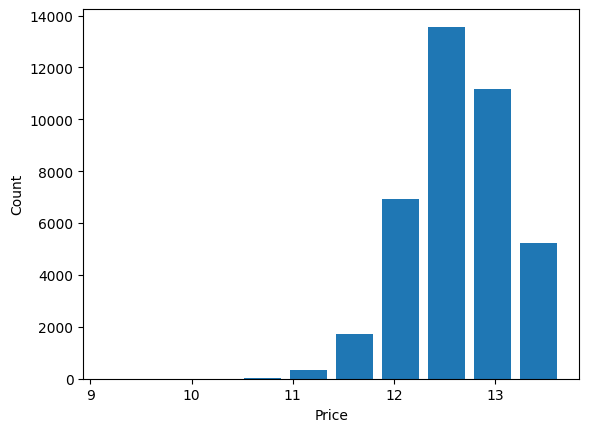

In [101]:
plt.hist(df_preprocessed.price, rwidth=0.8)
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

C:\Users\Emmanuel\AppData\Local\Temp\ipykernel_12536\3456620643.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




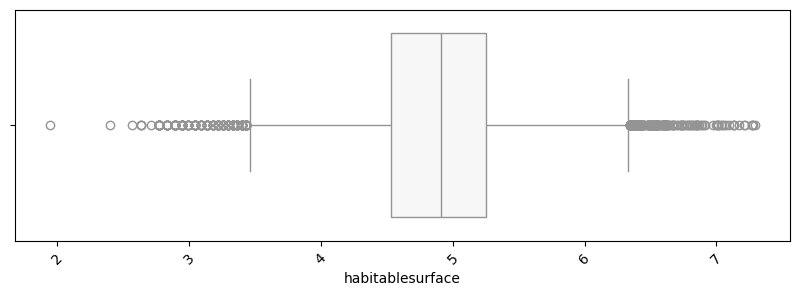

np.float64(7.290292882446597)

In [102]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(10, 3))

#df1 = df.groupby('type')['apartment'].apply(list).reset_index(name='new')
sns.boxplot(data=df_preprocessed, x='habitablesurface', width=0.8, palette="PRGn")
ax.tick_params(axis='x', rotation=45)
plt.show()

df_preprocessed['habitablesurface'].max()



In [103]:
from sklearn.metrics import classification_report, confusion_matrix
knn = KNeighborsClassifier(n_neighbors=7)

X = df_preprocessed.drop("price", axis=1).values
y = df_preprocessed["price"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

"""print(np.mean(X), np.std(X))
print(np.mean(X_train_scaled), np.std(X_train_scaled))"""



"""models = {"Logistic Regression": LogisticRegression(), "KNN": KNeighborsClassifier(),
"Decision Tree": DecisionTreeClassifier()}
results = []
for model in models.values():
    kf = KFold(n_splits=6, random_state=42, shuffle=True)
    cv_results = cross_val_score(model, X_train_scaled, y_train, cv=kf)
    results.append(cv_results)
plt.boxplot(results, labels=models.keys())
plt.show()"""

ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

In [ ]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
X = df_two_features.drop("price", axis=1).values
y = df_two_features["price"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg.fit(X_train_scaled, y_train)
y_pred = logreg.predict(X_test_scaled)
y_pred_probs = logreg.predict_proba(X_test_scaled)[:, 1]
print(y_pred_probs[0])

NameError: name 'df_two_features' is not defined